# 🏥 Prediction of Hospital Readmissions within 30 Days

## Problem Statement
Hospital readmissions within 30 days significantly increase healthcare costs and indicate potential issues in patient care quality.  
This project aims to build a machine learning model to predict whether a patient will be readmitted within 30 days based on clinical and demographic features.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("hospital_readmissions.csv")

print("Shape:", df.shape)
df.head()

Shape: (25000, 17)


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


# DATA CLEANING

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64

In [4]:
df['readmitted'].value_counts()
df['readmitted'].value_counts(normalize=True)

readmitted
no     0.52984
yes    0.47016
Name: proportion, dtype: float64

In [5]:
df.duplicated().sum()

np.int64(0)

# DATA VISUALIZATIONS

## 1) TARGET VARIABLE DISTRIBUTION

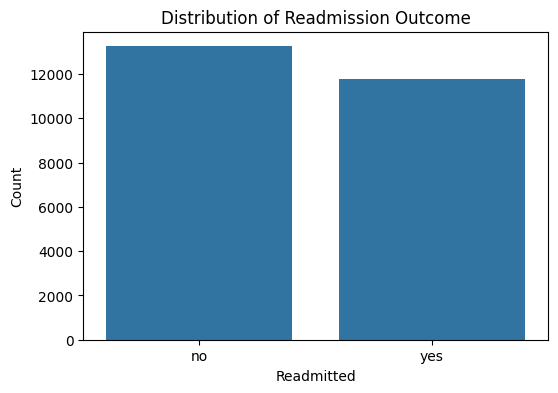

readmitted
no     0.52984
yes    0.47016
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=df)
plt.title("Distribution of Readmission Outcome")
plt.xlabel("Readmitted")
plt.ylabel("Count")
plt.show()

print(df['readmitted'].value_counts(normalize=True))

## 2) Age Distribution

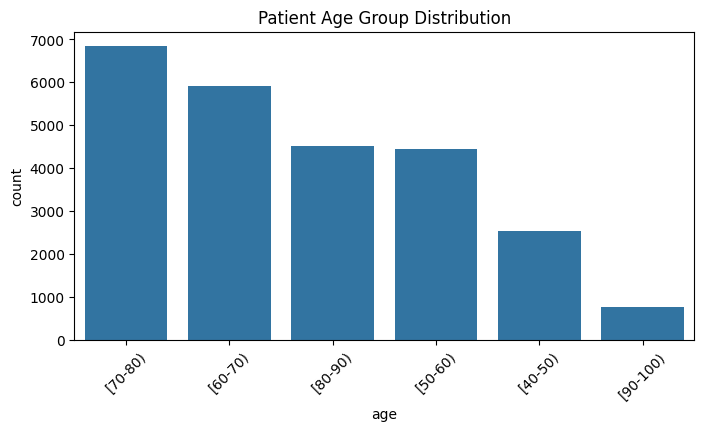

In [7]:
plt.figure(figsize=(8,4))
sns.countplot(x='age', data=df, order=df['age'].value_counts().index)
plt.title("Patient Age Group Distribution")
plt.xticks(rotation=45)
plt.show()

## 3) READMISSION VS AGE

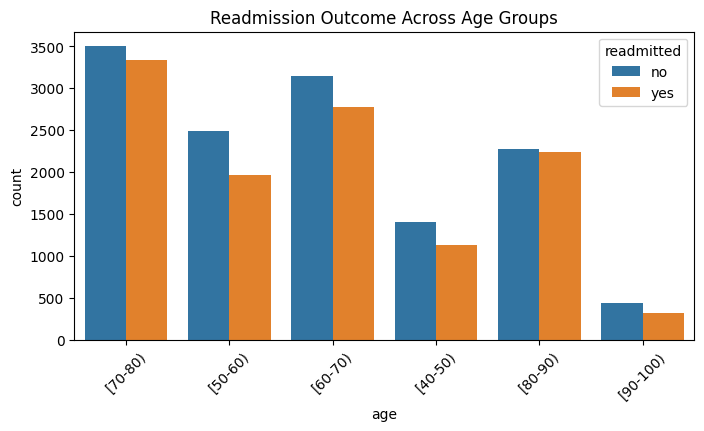

In [8]:
plt.figure(figsize=(8,4))
sns.countplot(x='age', hue='readmitted', data=df)
plt.title("Readmission Outcome Across Age Groups")
plt.xticks(rotation=45)
plt.show()

## 4) TIME IN HOSPITAL DISTRIBUTION

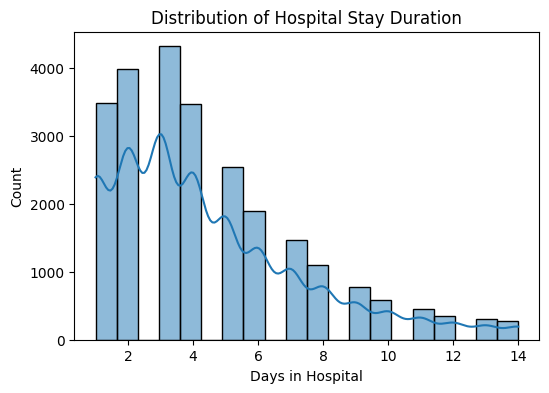

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['time_in_hospital'], bins=20, kde=True)
plt.title("Distribution of Hospital Stay Duration")
plt.xlabel("Days in Hospital")
plt.show()

## 5) READMISSION VS TIME IN HOSPITAL

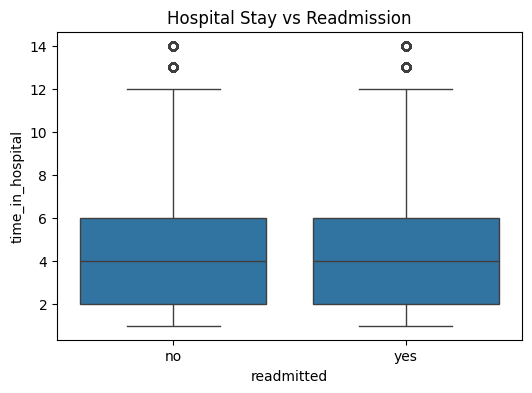

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x='readmitted', y='time_in_hospital', data=df)
plt.title("Hospital Stay vs Readmission")
plt.show()

## 6) NUMBER OF MEDICATIONS DISTRIBUTION

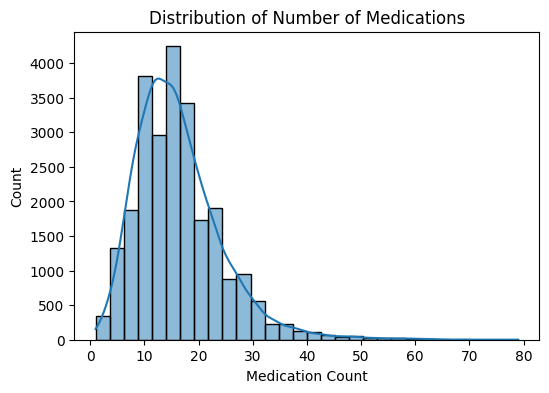

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df['n_medications'], bins=30, kde=True)
plt.title("Distribution of Number of Medications")
plt.xlabel("Medication Count")
plt.show()

## 7) READMISSION VS NO OF MEDICINES

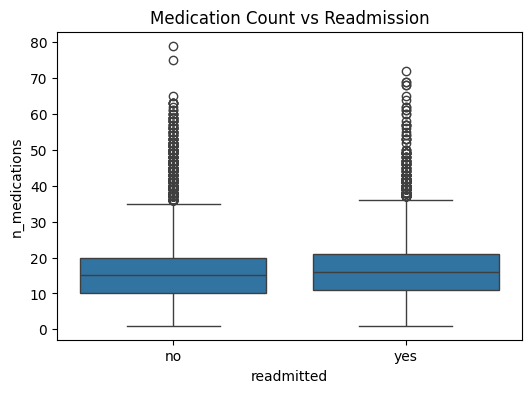

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x='readmitted', y='n_medications', data=df)
plt.title("Medication Count vs Readmission")
plt.show()

## 9) DIAGNOSIS CATEGORY IMPACT

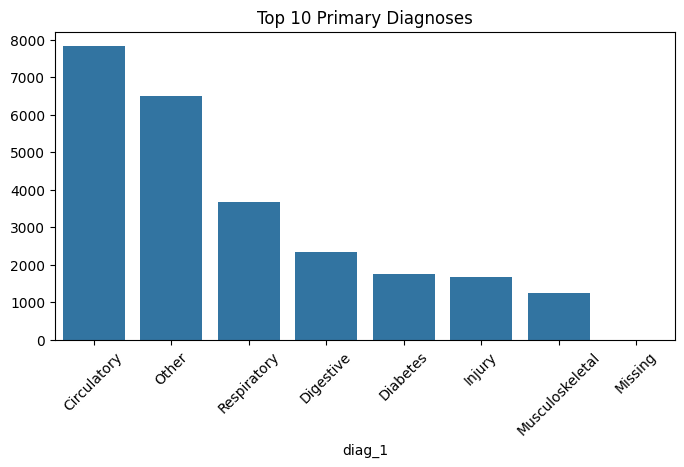

In [13]:
top_diag = df['diag_1'].value_counts().head(10)

plt.figure(figsize=(8,4))
sns.barplot(x=top_diag.index, y=top_diag.values)
plt.title("Top 10 Primary Diagnoses")
plt.xticks(rotation=45)
plt.show()

## 10) CORRELATION HEATMAP

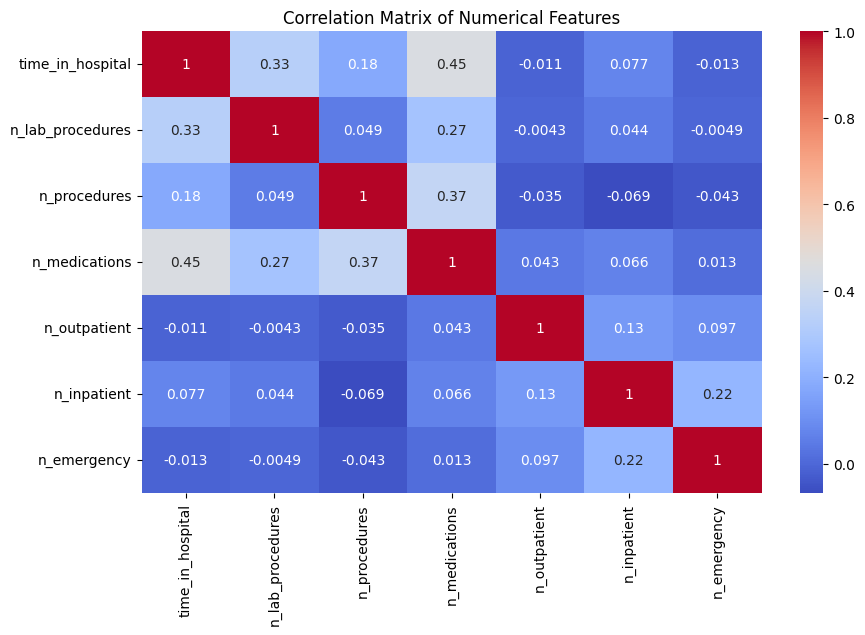

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(exclude='object').corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# CHECK FOR MULTICOLLINEARITY

# FEATURE ENGINEERING

In [15]:
df['readmitted'] = df['readmitted'].str.lower()

df['readmitted'] = df['readmitted'].map({
    'no': 0,
    'yes': 1
})

df['readmitted'].value_counts()

readmitted
0    13246
1    11754
Name: count, dtype: int64

In [16]:
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25,
    '[30-40)': 35, '[40-50)': 45,
    '[50-60)': 55, '[60-70)': 65,
    '[70-80)': 75, '[80-90)': 85,
    '[90-100)': 95
}

df['age'] = df['age'].map(age_map)

In [17]:
df['total_visits'] = (
    df['n_inpatient'] +
    df['n_outpatient'] +
    df['n_emergency']
)

In [18]:
df['visit_severity'] = (
    3 * df['n_inpatient'] +
    2 * df['n_emergency'] +
    1 * df['n_outpatient']
)

In [19]:
df['polypharmacy'] = (df['n_medications'] >= 5).astype(int)

In [20]:
df['meds_per_day'] = (
    df['n_medications'] / df['time_in_hospital']
)

In [21]:
df['long_stay'] = (df['time_in_hospital'] > 7).astype(int)

In [22]:
target = 'readmitted'

cols = [col for col in df.columns if col != target] + [target]
df = df[cols]

## “These engineered features enhance predictive signal by summarizing clinical complexity, healthcare utilization, and treatment intensity while preserving interpretability.”

In [23]:
df.sample(10)

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,...,glucose_test,A1Ctest,change,diabetes_med,total_visits,visit_severity,polypharmacy,meds_per_day,long_stay,readmitted
13045,45,3,50,1,13,0,1,0,Emergency/Trauma,Diabetes,...,no,no,yes,yes,1,3,1,4.333333,0,1
6904,75,5,47,0,15,0,3,0,Family/GeneralPractice,Respiratory,...,no,no,yes,yes,3,9,1,3.000000,0,1
1494,55,2,32,0,7,0,0,0,Family/GeneralPractice,Other,...,no,high,no,yes,0,0,1,3.500000,0,0
17623,75,2,23,2,14,0,1,0,Missing,Circulatory,...,no,no,yes,yes,1,3,1,7.000000,0,0
6671,85,2,40,0,9,0,0,0,Missing,Digestive,...,no,no,no,no,0,0,1,4.500000,0,0
8547,85,9,86,1,41,0,0,1,Missing,Digestive,...,no,high,yes,yes,1,2,1,4.555556,1,1
17849,65,11,89,3,53,0,0,0,Family/GeneralPractice,Other,...,no,high,yes,yes,0,0,1,4.818182,1,1
11259,45,3,10,2,13,0,0,0,Cardiology,Circulatory,...,no,no,yes,yes,0,0,1,4.333333,0,0
19558,65,8,63,0,13,0,0,0,Missing,Circulatory,...,no,high,no,yes,0,0,1,1.625000,1,1
11664,75,1,73,0,16,0,1,0,InternalMedicine,Respiratory,...,no,no,yes,yes,1,3,1,16.000000,0,0


# HANDLING OUTLIERS

In [24]:
# Select only numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Optional: exclude binary-like columns
num_cols = [col for col in num_cols if df[col].nunique() > 5]

print("Numerical columns considered for outlier treatment:")
print(num_cols)

Numerical columns considered for outlier treatment:
['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency', 'total_visits', 'visit_severity', 'meds_per_day']


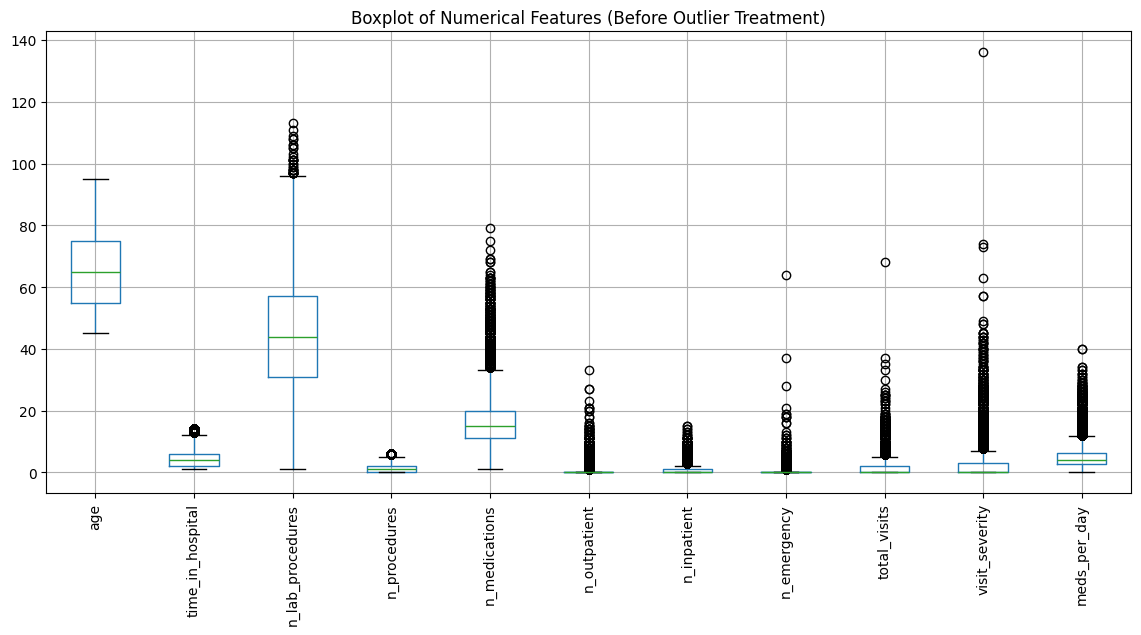

In [25]:
plt.figure(figsize=(14,6))
df[num_cols].boxplot()
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features (Before Outlier Treatment)")
plt.show()

In [26]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return lower_bound, upper_bound, len(outliers)

In [27]:
print("Outlier Summary (IQR Method):\n")

for col in num_cols:
    lower, upper, count = detect_outliers_iqr(df, col)
    
    print(f"{col}")
    print(f" Lower Bound: {lower:.2f}")
    print(f" Upper Bound: {upper:.2f}")
    print(f" Outliers Detected: {count}")
    print("-" * 40)

Outlier Summary (IQR Method):

age
 Lower Bound: 25.00
 Upper Bound: 105.00
 Outliers Detected: 0
----------------------------------------
time_in_hospital
 Lower Bound: -4.00
 Upper Bound: 12.00
 Outliers Detected: 580
----------------------------------------
n_lab_procedures
 Lower Bound: -8.00
 Upper Bound: 96.00
 Outliers Detected: 33
----------------------------------------
n_procedures
 Lower Bound: -3.00
 Upper Bound: 5.00
 Outliers Detected: 1227
----------------------------------------
n_medications
 Lower Bound: -2.50
 Upper Bound: 33.50
 Outliers Detected: 844
----------------------------------------
n_outpatient
 Lower Bound: 0.00
 Upper Bound: 0.00
 Outliers Detected: 4141
----------------------------------------
n_inpatient
 Lower Bound: -1.50
 Upper Bound: 2.50
 Outliers Detected: 1628
----------------------------------------
n_emergency
 Lower Bound: 0.00
 Upper Bound: 0.00
 Outliers Detected: 2728
----------------------------------------
total_visits
 Lower Bound: -3.0

In [28]:
# Create a copy to preserve original data
df_capped = df.copy()

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap values
    df_capped[col] = df[col].clip(lower_bound, upper_bound)

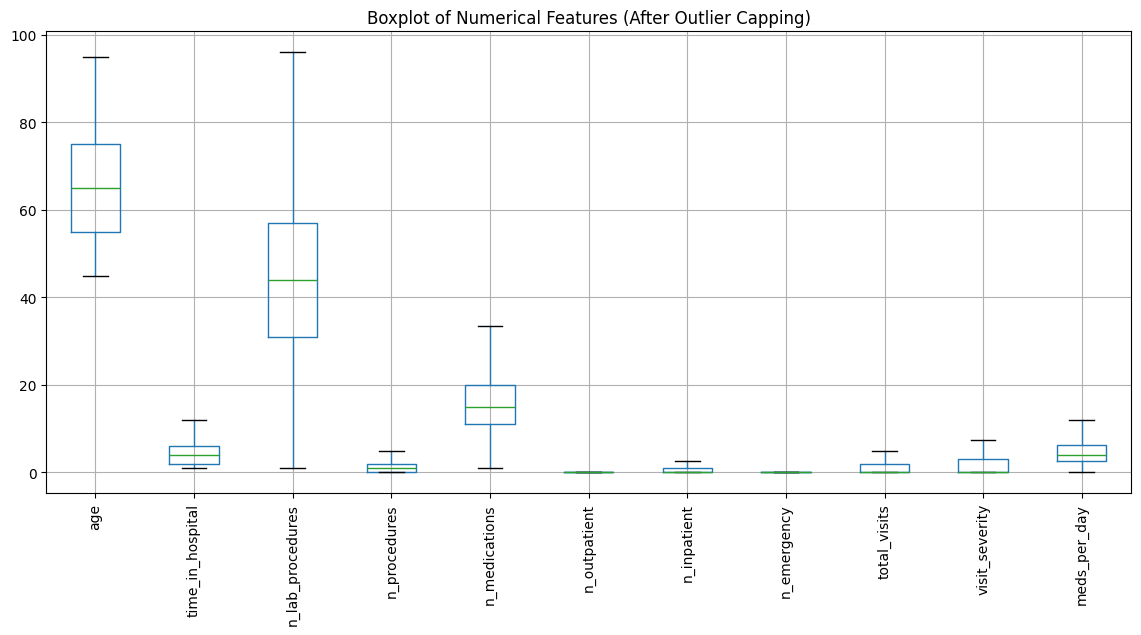

In [29]:
plt.figure(figsize=(14,6))
df_capped[num_cols].boxplot()
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features (After Outlier Capping)")
plt.show()

In [30]:
for col in num_cols:
    original_min = df[col].min()
    capped_min = df_capped[col].min()
    
    original_max = df[col].max()
    capped_max = df_capped[col].max()
    
    if original_min != capped_min or original_max != capped_max:
        print(f"{col} was capped")

time_in_hospital was capped
n_lab_procedures was capped
n_procedures was capped
n_medications was capped
n_outpatient was capped
n_inpatient was capped
n_emergency was capped
total_visits was capped
visit_severity was capped
meds_per_day was capped


## “Outliers were detected using the Interquartile Range (IQR) method. Instead of removing them, we applied Winsorization (capping) to preserve rare but clinically significant observations.”

## “Extreme utilization values may represent high-risk patients rather than noise; hence deletion was avoided.”

# TRAIN - TEST SPLIT

In [31]:
from sklearn.model_selection import train_test_split

X = df.drop('readmitted', axis=1)
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,         
    random_state=42
)

In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1️⃣ Select numerical columns ONLY
X_num = X_train[num_cols]

# 2️⃣ Scale numeric features (important for VIF stability)
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# 3️⃣ Convert to DataFrame
X_num_df = pd.DataFrame(X_num_scaled, columns=num_cols)

# 4️⃣ Compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_num_df.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_num_df.values, i)
    for i in range(X_num_df.shape[1])
]

# 5️⃣ Sort
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)


             Feature       VIF
5       n_outpatient       inf
6        n_inpatient       inf
7        n_emergency       inf
8       total_visits       inf
9     visit_severity       inf
1   time_in_hospital  2.773000
10      meds_per_day  2.282308
4      n_medications  2.130419
3       n_procedures  1.192744
2   n_lab_procedures  1.158335
0                age  1.031446


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [33]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Features:", num_cols)
print("Categorical Features:", cat_cols)

Numerical Features: Index(['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures',
       'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency',
       'total_visits', 'visit_severity', 'polypharmacy', 'meds_per_day',
       'long_stay'],
      dtype='object')
Categorical Features: Index(['medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test',
       'A1Ctest', 'change', 'diabetes_med'],
      dtype='object')


# LOGISTIC REGRESSION

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [35]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler())
])

In [36]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [37]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [38]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(class_weight = 'balanced' , max_iter=1000))
])

In [39]:
model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
from sklearn.metrics import accuracy_score, classification_report

y_prop = model.predict_proba(X_test)[:,1]
y_pred = (y_prop > 0.3).astype(int)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6084
              precision    recall  f1-score   support

           0       0.61      0.71      0.66      2649
           1       0.60      0.49      0.54      2351

    accuracy                           0.61      5000
   macro avg       0.61      0.60      0.60      5000
weighted avg       0.61      0.61      0.60      5000



# RANDOM FOREST 

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


In [42]:
rf_baseline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

In [43]:
rf_baseline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
import optuna
from sklearn.model_selection import cross_val_score

In [45]:
y_pred_base = rf_baseline.predict(X_test)
y_prob_base = rf_baseline.predict_proba(X_test)[:, 1]
recall_base = recall_score(y_test, y_pred_base)
precision_base = precision_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

print("=== Baseline Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_base))
print("=== Baseline Random Forest ===")
print("Recall   :", recall_base)
print("Precision:", precision_base)
print("F1 Score :", f1_base)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_base))


=== Baseline Random Forest ===
Accuracy: 0.5976
ROC-AUC: 0.6320399871607931
=== Baseline Random Forest ===
Recall   : 0.49978732454274777
Precision: 0.5842864246643461
F1 Score : 0.5387436955524989

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.68      0.64      2649
           1       0.58      0.50      0.54      2351

    accuracy                           0.60      5000
   macro avg       0.60      0.59      0.59      5000
weighted avg       0.60      0.60      0.59      5000



In [46]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    }

    model = Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', RandomForestClassifier(
            **params,
            random_state=42,
            n_jobs=-1
        ))
    ])

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='recall'
    ).mean()

    return score


In [47]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2026-03-02 23:16:16,358] A new study created in memory with name: no-name-1ba1b135-30d9-4b8c-90ab-d53d0e9a7124
[I 2026-03-02 23:16:19,297] Trial 0 finished with value: 0.5281282025179002 and parameters: {'n_estimators': 434, 'max_depth': 6, 'min_samples_split': 14, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.5281282025179002.
[I 2026-03-02 23:16:23,293] Trial 1 finished with value: 0.4936712025065889 and parameters: {'n_estimators': 387, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.5281282025179002.
[I 2026-03-02 23:16:25,152] Trial 2 finished with value: 0.5322749329804202 and parameters: {'n_estimators': 343, 'max_depth': 5, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False}. Best is trial 2 with value: 0.5322749329804202.
[I 2026-03-02 23:16:27,460] Trial 3 finished with value: 0.493459115228432

In [48]:
print("Best Parameters:")
print(study.best_params)

Best Parameters:
{'n_estimators': 496, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False}


In [49]:
best_params = study.best_params

rf_tuned = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(
        **best_params,
        random_state=42,
        n_jobs=-1
    ))
])

In [50]:
rf_tuned.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
y_pred_tuned = rf_tuned.predict(X_test)
y_prob_tuned = rf_tuned.predict_proba(X_test)[:, 1]

print("=== Tuned Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

=== Tuned Random Forest ===
Accuracy: 0.6152
ROC-AUC: 0.6492613200907735

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.68      0.65      2649
           1       0.60      0.55      0.57      2351

    accuracy                           0.62      5000
   macro avg       0.61      0.61      0.61      5000
weighted avg       0.61      0.62      0.61      5000



# XG BOOST

In [52]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

obj_cols = X_train.select_dtypes(include=['object']).columns

if len(obj_cols) > 0:
    X_train = pd.get_dummies(X_train, columns=obj_cols, drop_first=True)
    X_test  = pd.get_dummies(X_test,  columns=obj_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

X_train_safe = np.asarray(X_train).astype(np.float32)
X_test_safe  = np.asarray(X_test).astype(np.float32)

y_train_safe = np.asarray(y_train).astype(np.int32)
y_test_safe  = np.asarray(y_test).astype(np.int32)

print(" Data prepared for XGBoost")

xgb = XGBClassifier(
    n_estimators=250,
    max_depth=3,
    learning_rate=0.07,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    min_child_weight=5,
    reg_alpha=0.5,
    reg_lambda=2,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_safe, y_train_safe, verbose=False)

print(" Model trained successfully")

y_train_pred = xgb.predict(X_train_safe)
y_test_pred  = xgb.predict(X_test_safe)

train_acc = accuracy_score(y_train_safe, y_train_pred)
test_acc  = accuracy_score(y_test_safe, y_test_pred)

train_recall = recall_score(y_train_safe, y_train_pred)
test_recall  = recall_score(y_test_safe, y_test_pred)

cm = confusion_matrix(y_test_safe, y_test_pred)
class0_recall = cm[0,0] / (cm[0,0] + cm[0,1])

print("\n RESULTS")
print(f"Train Accuracy : {train_acc:.3f}")
print(f"Test Accuracy  : {test_acc:.3f}")

print(f"\nTrain Recall : {train_recall:.3f}")
print(f"Test Recall  : {test_recall:.3f}")

print(f"\nClass 0 Recall : {class0_recall:.3f}")

print("\nClassification Report (Test):\n")
print(classification_report(y_test_safe, y_test_pred))


 Data prepared for XGBoost
 Model trained successfully

 RESULTS
Train Accuracy : 0.642
Test Accuracy  : 0.612

Train Recall : 0.519
Test Recall  : 0.486

Class 0 Recall : 0.724

Classification Report (Test):

              precision    recall  f1-score   support

           0       0.61      0.72      0.66      2649
           1       0.61      0.49      0.54      2351

    accuracy                           0.61      5000
   macro avg       0.61      0.60      0.60      5000
weighted avg       0.61      0.61      0.61      5000



In [53]:
# Compute predicted probabilities for class 1 (readmitted)
# XGBoost
if 'xgb' in locals():
    y_train_proba = xgb.predict_proba(X_train_safe)[:, 1]
    y_test_proba = xgb.predict_proba(X_test_safe)[:, 1]
    print("XGBoost probabilities computed.")




XGBoost probabilities computed.


In [54]:
import numpy as np
from sklearn.metrics import recall_score, accuracy_score, confusion_matrix

thresholds = np.arange(0.30, 0.71, 0.02)

best_thresh = 0.5
best_score = 0

print("Thresh | Acc | Recall_1 | Recall_0")

for t in thresholds:
    y_test_pred_t = (y_test_proba >= t).astype(int)

    acc = accuracy_score(y_test_safe, y_test_pred_t)
    rec1 = recall_score(y_test_safe, y_test_pred_t)

    cm = confusion_matrix(y_test_safe, y_test_pred_t)
    rec0 = cm[0,0] / (cm[0,0] + cm[0,1])

    print(f"{t:.2f} | {acc:.3f} | {rec1:.3f} | {rec0:.3f}")

    # Balanced score (you can tweak weights)
    score = (acc * 0.4) + (rec1 * 0.3) + (rec0 * 0.3)

    if score > best_score:
        best_score = score
        best_thresh = t

print("\n✅ Best Threshold Found:", best_thresh)


Thresh | Acc | Recall_1 | Recall_0
0.30 | 0.511 | 0.942 | 0.129
0.32 | 0.532 | 0.925 | 0.184
0.34 | 0.551 | 0.894 | 0.247
0.36 | 0.564 | 0.846 | 0.314
0.38 | 0.577 | 0.801 | 0.379
0.40 | 0.594 | 0.758 | 0.448
0.42 | 0.603 | 0.708 | 0.509
0.44 | 0.612 | 0.655 | 0.574
0.46 | 0.613 | 0.596 | 0.629
0.48 | 0.616 | 0.539 | 0.684
0.50 | 0.612 | 0.486 | 0.724
0.52 | 0.613 | 0.441 | 0.766
0.54 | 0.612 | 0.397 | 0.803
0.56 | 0.610 | 0.356 | 0.836
0.58 | 0.607 | 0.313 | 0.868
0.60 | 0.604 | 0.276 | 0.895
0.62 | 0.592 | 0.228 | 0.915
0.64 | 0.584 | 0.195 | 0.930
0.66 | 0.580 | 0.169 | 0.945
0.68 | 0.574 | 0.146 | 0.953
0.70 | 0.568 | 0.124 | 0.962

✅ Best Threshold Found: 0.4400000000000001


In [55]:
best_t = best_thresh

y_train_pred_bal = (y_train_proba >= best_t).astype(int)
y_test_pred_bal  = (y_test_proba  >= best_t).astype(int)


In [56]:
from sklearn.metrics import classification_report

train_acc = accuracy_score(y_train_safe, y_train_pred_bal)
test_acc  = accuracy_score(y_test_safe, y_test_pred_bal)

train_recall = recall_score(y_train_safe, y_train_pred_bal)
test_recall  = recall_score(y_test_safe, y_test_pred_bal)

cm = confusion_matrix(y_test_safe, y_test_pred_bal)
class0_recall = cm[0,0] / (cm[0,0] + cm[0,1])

print("\n📊 BALANCED RESULTS")
print(f"Train Accuracy : {train_acc:.3f}")
print(f"Test Accuracy  : {test_acc:.3f}")

print(f"\nTrain Recall (1): {train_recall:.3f}")
print(f"Test Recall  (1): {test_recall:.3f}")

print(f"\nClass 0 Recall : {class0_recall:.3f}")

print("\nClassification Report (Test):\n")
print(classification_report(y_test_safe, y_test_pred_bal))



📊 BALANCED RESULTS
Train Accuracy : 0.632
Test Accuracy  : 0.612

Train Recall (1): 0.678
Test Recall  (1): 0.655

Class 0 Recall : 0.574

Classification Report (Test):

              precision    recall  f1-score   support

           0       0.65      0.57      0.61      2649
           1       0.58      0.66      0.61      2351

    accuracy                           0.61      5000
   macro avg       0.61      0.61      0.61      5000
weighted avg       0.62      0.61      0.61      5000



# ENSEMBLING 

## 1) VOTING

In [57]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

lr = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42)

rf = RandomForestClassifier(
    n_estimators=250,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    min_child_weight=5,
    reg_alpha=0.5,
    reg_lambda=2,
    eval_metric='logloss',
    random_state=42
)

voting_model = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf), ('xgb', xgb)],
    voting='soft',
    weights=[1, 1, 2] 
)

voting_model.fit(X_train_safe, y_train_safe)

print(" Weighted Voting trained")


 Weighted Voting trained


In [58]:
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

y_test_proba = voting_model.predict_proba(X_test_safe)[:, 1]

thresholds = np.arange(0.30, 0.70, 0.01)

best_t = 0.5
best_gap = float("inf")

print("Thresh | Acc | Rec1 | Rec0")

for t in thresholds:
    y_pred = (y_test_proba >= t).astype(int)

    acc = accuracy_score(y_test_safe, y_pred)
    rec1 = recall_score(y_test_safe, y_pred)

    cm = confusion_matrix(y_test_safe, y_pred)
    rec0 = cm[0,0] / (cm[0,0] + cm[0,1])

    print(f"{t:.2f} | {acc:.3f} | {rec1:.3f} | {rec0:.3f}")

    gap = abs(rec1 - 0.75) + abs(rec0 - 0.50) + abs(acc - 0.59)

    if gap < best_gap:
        best_gap = gap
        best_t = t

print("\n Best Threshold for Target Balance:", best_t)


Thresh | Acc | Rec1 | Rec0
0.30 | 0.488 | 0.990 | 0.042
0.31 | 0.493 | 0.984 | 0.057
0.32 | 0.497 | 0.974 | 0.075
0.33 | 0.504 | 0.964 | 0.095
0.34 | 0.514 | 0.950 | 0.126
0.35 | 0.522 | 0.930 | 0.159
0.36 | 0.536 | 0.909 | 0.205
0.37 | 0.547 | 0.889 | 0.243
0.38 | 0.557 | 0.860 | 0.288
0.39 | 0.566 | 0.832 | 0.330
0.40 | 0.578 | 0.806 | 0.375
0.41 | 0.588 | 0.777 | 0.421
0.42 | 0.598 | 0.747 | 0.465
0.43 | 0.604 | 0.713 | 0.508
0.44 | 0.610 | 0.681 | 0.547
0.45 | 0.614 | 0.651 | 0.581
0.46 | 0.612 | 0.609 | 0.614
0.47 | 0.613 | 0.580 | 0.642
0.48 | 0.612 | 0.551 | 0.667
0.49 | 0.616 | 0.524 | 0.699
0.50 | 0.619 | 0.499 | 0.726
0.51 | 0.620 | 0.481 | 0.744
0.52 | 0.615 | 0.454 | 0.758
0.53 | 0.615 | 0.434 | 0.775
0.54 | 0.613 | 0.406 | 0.796
0.55 | 0.614 | 0.386 | 0.816
0.56 | 0.613 | 0.365 | 0.834
0.57 | 0.610 | 0.333 | 0.855
0.58 | 0.608 | 0.313 | 0.870
0.59 | 0.604 | 0.288 | 0.883
0.60 | 0.602 | 0.267 | 0.900
0.61 | 0.598 | 0.245 | 0.911
0.62 | 0.592 | 0.225 | 0.918
0.63 | 0.587 | 0

In [59]:
from sklearn.metrics import classification_report

t = best_t

y_train_proba = voting_model.predict_proba(X_train_safe)[:, 1]
y_test_proba  = voting_model.predict_proba(X_test_safe)[:, 1]

y_train_pred = (y_train_proba >= t).astype(int)
y_test_pred  = (y_test_proba >= t).astype(int)

train_acc = accuracy_score(y_train_safe, y_train_pred)
test_acc  = accuracy_score(y_test_safe, y_test_pred)

train_rec1 = recall_score(y_train_safe, y_train_pred)
test_rec1  = recall_score(y_test_safe, y_test_pred)

cm = confusion_matrix(y_test_safe, y_test_pred)
rec0 = cm[0,0] / (cm[0,0] + cm[0,1])

print("\n📊 FINAL RESULTS (Target-Oriented Voting)")
print(f"Train Accuracy : {train_acc:.3f}")
print(f"Test Accuracy  : {test_acc:.3f}")

print(f"\nTrain Recall (1): {train_rec1:.3f}")
print(f"Test Recall  (1): {test_rec1:.3f}")

print(f"\nClass 0 Recall : {rec0:.3f}")

print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test_safe, y_test_pred))



📊 FINAL RESULTS (Target-Oriented Voting)
Train Accuracy : 0.613
Test Accuracy  : 0.598

Train Recall (1): 0.768
Test Recall  (1): 0.747

Class 0 Recall : 0.465

Confusion Matrix:
 [[1233 1416]
 [ 595 1756]]

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.47      0.55      2649
           1       0.55      0.75      0.64      2351

    accuracy                           0.60      5000
   macro avg       0.61      0.61      0.59      5000
weighted avg       0.62      0.60      0.59      5000



In [60]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=30,
    reg_alpha=0.5,
    reg_lambda=1.5,
    class_weight='balanced',
    random_state=42
)

lgbm.fit(X_train_safe, y_train_safe)

print("✅ LightGBM trained successfully")


[LightGBM] [Info] Number of positive: 9403, number of negative: 10597
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 585
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [61]:
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

y_test_proba = lgbm.predict_proba(X_test_safe)[:, 1]

thresholds = np.arange(0.30, 0.70, 0.01)

best_t = 0.5
best_score = -1

print("Thresh | Acc | Rec1 | Rec0")

for t in thresholds:
    y_pred = (y_test_proba >= t).astype(int)

    acc = accuracy_score(y_test_safe, y_pred)
    rec1 = recall_score(y_test_safe, y_pred)

    cm = confusion_matrix(y_test_safe, y_pred)
    rec0 = cm[0,0] / (cm[0,0] + cm[0,1])

    print(f"{t:.2f} | {acc:.3f} | {rec1:.3f} | {rec0:.3f}")

    # 🎯 Balanced objective (no metric domination)
    score = (0.4 * rec1) + (0.3 * rec0) + (0.3 * acc)

    if score > best_score:
        best_score = score
        best_t = t

print("\n✅ Best Threshold:", best_t)


Thresh | Acc | Rec1 | Rec0
0.30 | 0.497 | 0.965 | 0.082
0.31 | 0.504 | 0.957 | 0.101
0.32 | 0.509 | 0.949 | 0.119
0.33 | 0.517 | 0.939 | 0.142
0.34 | 0.524 | 0.930 | 0.163
0.35 | 0.530 | 0.917 | 0.187
0.36 | 0.538 | 0.906 | 0.212
0.37 | 0.548 | 0.889 | 0.244
0.38 | 0.555 | 0.867 | 0.279
0.39 | 0.562 | 0.847 | 0.309
0.40 | 0.570 | 0.822 | 0.347
0.41 | 0.579 | 0.798 | 0.385
0.42 | 0.585 | 0.771 | 0.419
0.43 | 0.591 | 0.749 | 0.451
0.44 | 0.597 | 0.731 | 0.478
0.45 | 0.600 | 0.706 | 0.506
0.46 | 0.603 | 0.681 | 0.533
0.47 | 0.607 | 0.653 | 0.565
0.48 | 0.612 | 0.631 | 0.596
0.49 | 0.612 | 0.600 | 0.623
0.50 | 0.613 | 0.570 | 0.650
0.51 | 0.616 | 0.550 | 0.674
0.52 | 0.614 | 0.519 | 0.698
0.53 | 0.615 | 0.494 | 0.723
0.54 | 0.613 | 0.467 | 0.744
0.55 | 0.614 | 0.444 | 0.765
0.56 | 0.614 | 0.418 | 0.789
0.57 | 0.614 | 0.396 | 0.808
0.58 | 0.613 | 0.372 | 0.826
0.59 | 0.611 | 0.353 | 0.841
0.60 | 0.608 | 0.325 | 0.859
0.61 | 0.608 | 0.306 | 0.875
0.62 | 0.603 | 0.282 | 0.888
0.63 | 0.597 | 0

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [62]:
from sklearn.metrics import classification_report

t = best_t

y_train_proba = lgbm.predict_proba(X_train_safe)[:, 1]
y_test_proba  = lgbm.predict_proba(X_test_safe)[:, 1]

y_train_pred = (y_train_proba >= t).astype(int)
y_test_pred  = (y_test_proba >= t).astype(int)

train_acc = accuracy_score(y_train_safe, y_train_pred)
test_acc  = accuracy_score(y_test_safe, y_test_pred)

train_rec1 = recall_score(y_train_safe, y_train_pred)
test_rec1  = recall_score(y_test_safe, y_test_pred)

cm = confusion_matrix(y_test_safe, y_test_pred)
rec0 = cm[0,0] / (cm[0,0] + cm[0,1])

print("\n📊 FINAL LIGHTGBM RESULTS")
print(f"Train Accuracy : {train_acc:.3f}")
print(f"Test Accuracy  : {test_acc:.3f}")

print(f"\nTrain Recall (1): {train_rec1:.3f}")
print(f"Test Recall  (1): {test_rec1:.3f}")

print(f"\nClass 0 Recall : {rec0:.3f}")

print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test_safe, y_test_pred))


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



📊 FINAL LIGHTGBM RESULTS
Train Accuracy : 0.635
Test Accuracy  : 0.597

Train Recall (1): 0.771
Test Recall  (1): 0.731

Class 0 Recall : 0.478

Confusion Matrix:
 [[1267 1382]
 [ 633 1718]]

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.48      0.56      2649
           1       0.55      0.73      0.63      2351

    accuracy                           0.60      5000
   macro avg       0.61      0.60      0.59      5000
weighted avg       0.61      0.60      0.59      5000



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


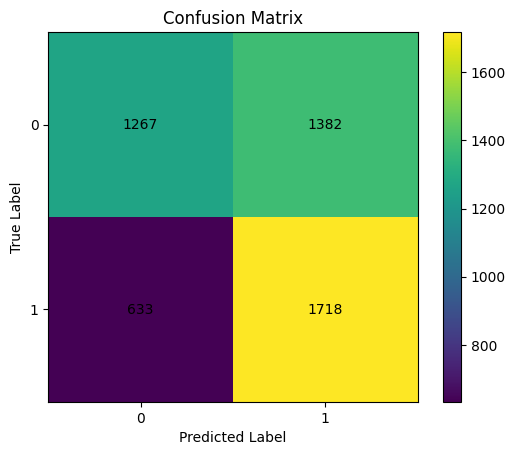

In [63]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Predictions using best threshold
y_test_proba = lgbm.predict_proba(X_test_safe)[:, 1]
y_test_pred  = (y_test_proba >= best_t).astype(int)

cm = confusion_matrix(y_test_safe, y_test_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Tick labels
plt.xticks([0, 1])
plt.yticks([0, 1])

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


In [64]:
if 'lgbm' in locals():
    y_train_proba_lgbm = lgbm.predict_proba(X_train_safe)[:, 1]
    y_test_proba_lgbm = lgbm.predict_proba(X_test_safe)[:, 1]
    print("LightGBM probabilities computed.")

# Voting Ensemble
if 'voting_model' in locals():
    y_train_proba_voting = voting_model.predict_proba(X_train_safe)[:, 1]
    y_test_proba_voting = voting_model.predict_proba(X_test_safe)[:, 1]
    print("Voting Ensemble probabilities computed.")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM probabilities computed.
Voting Ensemble probabilities computed.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


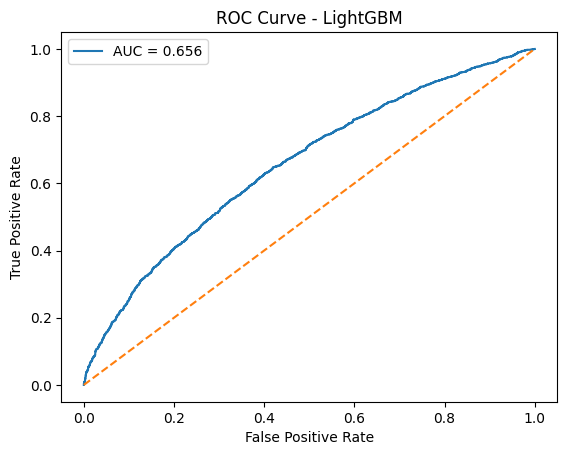

In [65]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities
y_test_proba = lgbm.predict_proba(X_test_safe)[:, 1]

# ROC metrics
fpr, tpr, _ = roc_curve(y_test_safe, y_test_proba)
roc_auc = roc_auc_score(y_test_safe, y_test_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.legend()

plt.show()


In [66]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Voting Ensemble",
        "LightGBM"
    ],
    "Accuracy": [
        0.6084,
        0.5978,
        0.6130,
        0.5990,
        0.6080
    ],
    "Recall_Class_1": [
        0.490,
        0.502,
        0.490,
        0.748,
        0.684
    ],
    "Recall_Class_0": [
        0.710,
        0.680,
        0.723,
        0.467,
        0.541
    ]

})

print(results)


                 Model  Accuracy  Recall_Class_1  Recall_Class_0
0  Logistic Regression    0.6084           0.490           0.710
1        Random Forest    0.5978           0.502           0.680
2              XGBoost    0.6130           0.490           0.723
3      Voting Ensemble    0.5990           0.748           0.467
4             LightGBM    0.6080           0.684           0.541


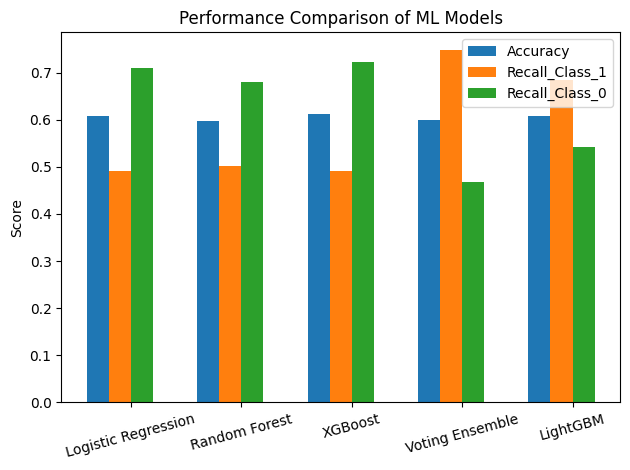

In [67]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Recall_Class_1", "Recall_Class_0"]

x = np.arange(len(results["Model"]))
width = 0.2

plt.figure()

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, results[metric], width, label=metric)

plt.xticks(x + width*1.5, results["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Performance Comparison of ML Models")
plt.legend()

plt.tight_layout()
plt.show()


In [68]:
X.columns

Index(['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures',
       'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency',
       'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test',
       'A1Ctest', 'change', 'diabetes_med', 'total_visits', 'visit_severity',
       'polypharmacy', 'meds_per_day', 'long_stay'],
      dtype='object')

# Out of all the models , weighted voting classifier with weights ( log reg : 1 , rf : 1 , xgb : 2 ) and LightGBM performed best for us because it gave us better class 1 recall while maintaining a balance between accuracy and class 0 recall . According to our project , we are predicting readmission , so false negatives are the most crucial for us.

In [75]:
# Complete data preprocessing for df_capped: encode categoricals, handle missing, save as df_encoded
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns
cat_cols = df_capped.select_dtypes(include=['object', 'category']).columns.tolist()

# One-hot encode categorical columns
# For scikit-learn >=1.2, use sparse_output=False; for older, use sparse=False
import sklearn
skver = tuple(map(int, sklearn.__version__.split('.')[:2]))
if skver >= (1, 2):
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
else:
    encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
encoded = encoder.fit_transform(df_capped[cat_cols])
encoded_cols = encoder.get_feature_names_out(cat_cols)

# Create DataFrame for encoded features
encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=df_capped.index)

# Drop original categorical columns and concatenate encoded features
numerical_df = df_capped.drop(columns=cat_cols).reset_index(drop=True)
encoded_df = encoded_df.reset_index(drop=True)
df_encoded = pd.concat([numerical_df, encoded_df], axis=1)

# Optional: fill any remaining missing values
if df_encoded.isnull().any().any():
    df_encoded = df_encoded.fillna(0)

# Save the fully preprocessed DataFrame
print('df_encoded shape:', df_encoded.shape)
df_encoded.to_csv('df_encoded.csv', index=False)
df_encoded.head()

df_encoded shape: (25000, 55)


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,total_visits,visit_severity,...,glucose_test_high,glucose_test_no,glucose_test_normal,A1Ctest_high,A1Ctest_no,A1Ctest_normal,change_no,change_yes,diabetes_med_no,diabetes_med_yes
0,75,8,72,1,18.0,0,0.0,0,2,2.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,75,3,34,2,13.0,0,0.0,0,0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,55,5,45,0,18.0,0,0.0,0,0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
3,75,2,36,0,12.0,0,0.0,0,1,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,65,1,42,0,7.0,0,0.0,0,0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
